In [3]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd
import frequency_func as ff
from scipy.optimize import curve_fit
plt.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
import math

In [19]:
outfile_name="km"
Tcm=32
dm2=1e-18
ke=0.9
km=1.8
B_lin=np.linspace(0,1,5)
ax_lin=np.linspace(-1,1,5)
A=0.9/np.max((ke**3,km**3))
e_i=15
e0=math.log(ke/km)*3/(ke-km)

In [20]:
sins=np.array((0.8,0.3,0.1,0.01,0.6))
coss=np.sqrt(1-(sins**2))
Bs=np.array((sins,[0]*len(sins),-1*coss))
ang_l=len(sins)

In [34]:
vecs=np.empty((3,ang_l,1001,206),dtype=float)
Vs=np.empty((ang_l,1001))
r=np.empty((ang_l,206))
af=np.empty((ang_l))
S0=np.empty((ang_l)) # essentially 'g' in our pendulum
time=np.empty((ang_l,1001))
for i in range(ang_l):
    pd.run_coherentsolve(outfile_name, Tcm, dm2, ke, km, ke, km, sins[i])
    data=ff.return_data(outfile_name)

    P0, Px, Py, Pz = pd.make_P(data['rho'])
    P0bar, Pxbar, Pybar, Pzbar = pd.make_P(data['rhobar'])
    eps = data['eps']
    w=data['w']
    time[i]=data['time']

    S=np.array([(P0*Px)+(P0bar*Pxbar),(P0*Py)+(P0bar*Pybar),(P0*Pz)+(P0bar*Pzbar)])
    B_angle=np.empty((len(time[i]),len(eps)),dtype=float)
    V=pd.V_mat(data)
    s0=0
    for e in range(len(eps)):
        for t in range(len(time[i])):
            B_angle[t,e]=np.dot(Bs[:,i],S[:,t,e])/np.linalg.norm(S[:,t,e])
        r[i,e]=np.sqrt(Px[0,e]**2+Pz[0,e]**2)
        s0+=w[e]*eps[e]*(r[i,e])*np.sign(B_angle[0,e])
    S0[i]=s0*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*0.25/(np.pi**2)
    vecs[0,i]=B_angle
    vecs[1,i]=Px
    vecs[2,i]=Pz
    Vs[i]=V[1]
    freq=ff.frequency(data,dm2)
    co0=freq[1]
    af[i]=freq[3]

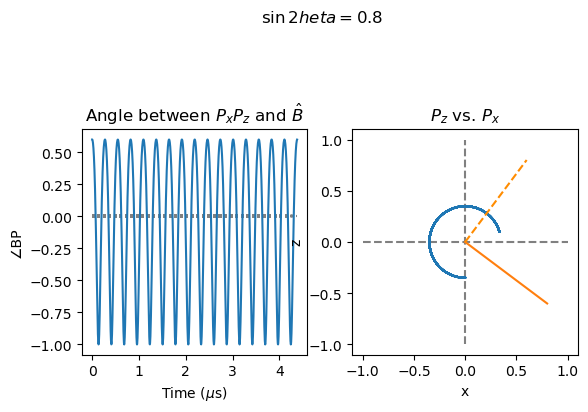

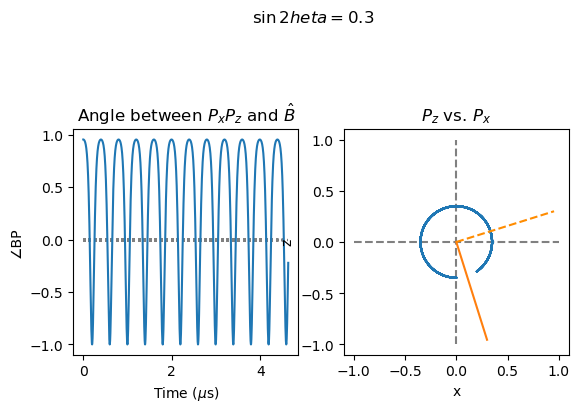

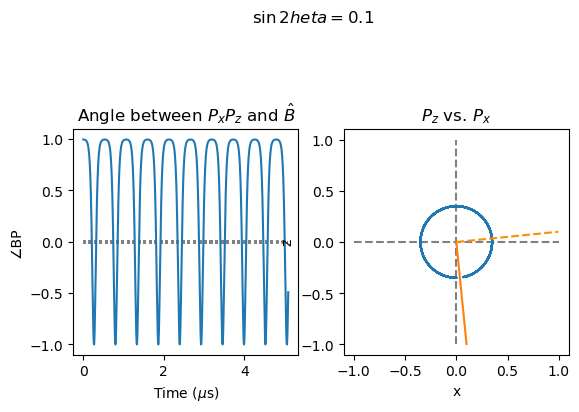

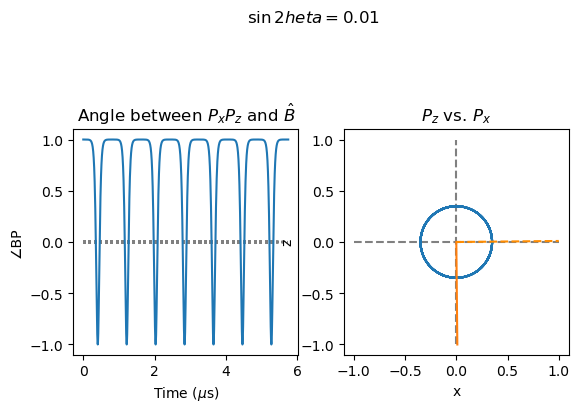

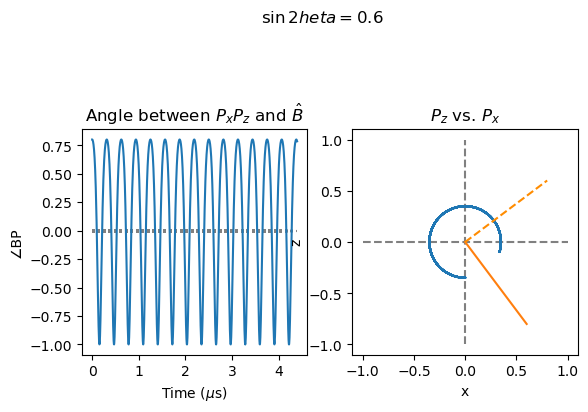

In [35]:
e_i=15
for i in range(ang_l):
    fig,(ax1,ax2)=plt.subplots(1,2)
    fig.suptitle('$\sin 2 \theta=$'+str(sins[i]))

    ax1.set_box_aspect(1)
    ax1.set_title('Angle between $P_xP_z$ and $\hat{B}$')
    ax1.set_xlabel('Time ($\mu$s)')
    ax1.set_ylabel('∠BP')
    ax1.plot(np.linspace(0,time[i,:-1],2),[0]*2,':',color='gray')
    ax1.plot(time[i],vecs[0,i,:,e_i])
    # plt.scatter(time_f[extf[::4]],B_anglef[extf[::4],e])
    # plt.scatter(time_f[extf[1::4]],B_anglef[extf[1::4],e])
    # plt.xlim(10,17.5)

    ax2.set_box_aspect(1)
    ax2.set_title('$P_z$ vs. $P_x$')
    ax2.set_xlabel('x')
    ax2.set_ylabel('z')
    ax2.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
    ax2.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
    ax2.plot(vecs[1,i,:,e_i],vecs[2,i,:,e_i])
    ax2.plot(B_lin*Bs[0,i],B_lin*Bs[2,i],label='B')
    ax2.plot(B_lin*-1*Bs[2,i],B_lin*Bs[0,i],'--',label='B⊥',color='darkorange')
    # plt.scatter(Pxf[extf[::4],e],Pzf[extf[::4],e])
    # plt.scatter(Pxf[extf[1::4],e],Pzf[extf[1::4],e])

#     plt.tight_layout()

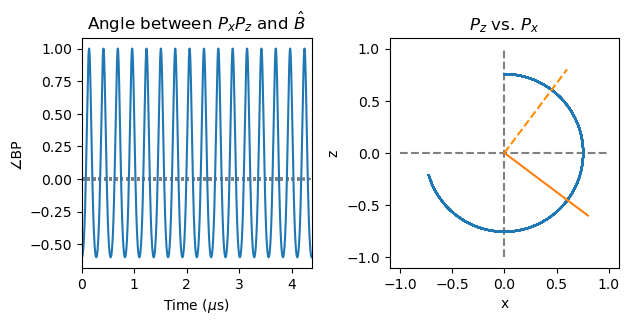

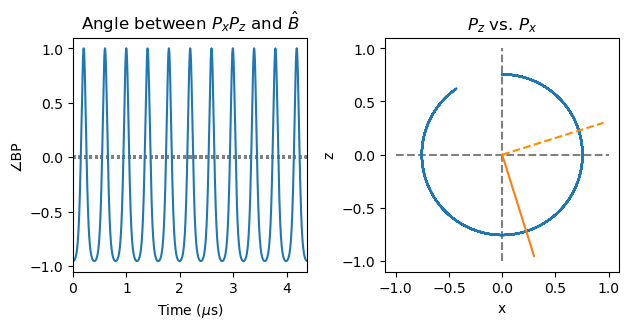

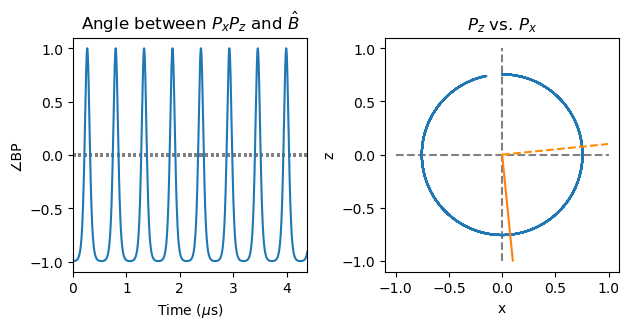

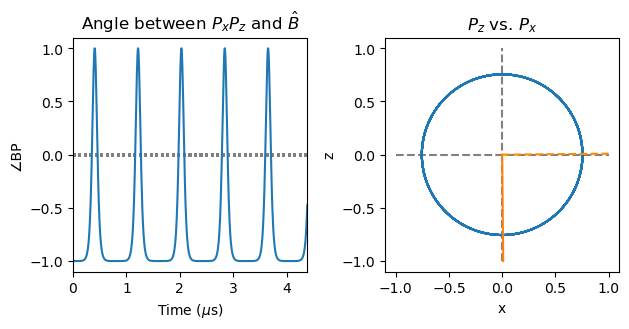

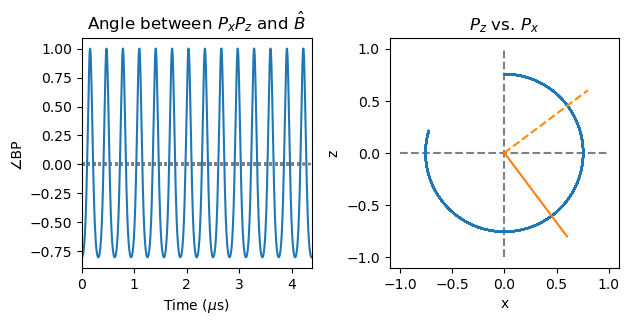

In [47]:
e_i=45
for i in range(ang_l):
    fig,(ax1,ax2)=plt.subplots(1,2)
#     fig.suptitle('$\sin 2 \theta=$'+str(sins[i]))

    ax1.set_box_aspect(1)
    ax1.set_title('Angle between $P_xP_z$ and $\hat{B}$')
    ax1.set_xlabel('Time ($\mu$s)')
    ax1.set_ylabel('∠BP')
    ax1.plot(np.linspace(0,time[i,:-1],2),[0]*2,':',color='gray')
    ax1.plot(time[i],vecs[0,i,:,e_i])
    # plt.scatter(time_f[extf[::4]],B_anglef[extf[::4],e])
    # plt.scatter(time_f[extf[1::4]],B_anglef[extf[1::4],e])
    # plt.xlim(10,17.5)
    ax1.set_xlim(0,time[0,-1])

    ax2.set_box_aspect(1)
    ax2.set_title('$P_z$ vs. $P_x$')
    ax2.set_xlabel('x')
    ax2.set_ylabel('z')
    ax2.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
    ax2.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
    ax2.plot(vecs[1,i,:,e_i],vecs[2,i,:,e_i])
    ax2.plot(B_lin*Bs[0,i],B_lin*Bs[2,i],label='B')
    ax2.plot(B_lin*-1*Bs[2,i],B_lin*Bs[0,i],'--',label='B⊥',color='darkorange')

    # plt.scatter(Pxf[extf[::4],e],Pzf[extf[::4],e])
    # plt.scatter(Pxf[extf[1::4],e],Pzf[extf[1::4],e])

    plt.tight_layout()

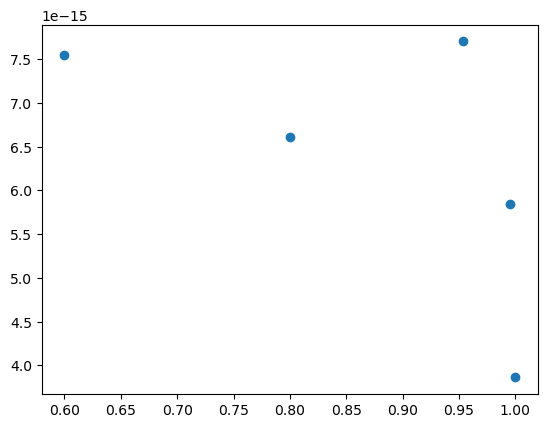

In [44]:
plt.scatter(coss,af)